# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test1 io profiles

Notebook equivalent of `tests/3_solar/test1_io_profiles.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `solar` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `solar` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test1_io_profiles"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "3_solar" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\3_solar\test1_io_profiles.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `solar` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\solar\test1_io_profiles


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_load_b16_solar_model`

**What is checked:** Load b16 solar model behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Radius must be 1D; density shape must match radius; 8B source must be available; density must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_load_b16_solar_model)


Running test_load_b16_solar_model ...

Loaded B16 solar model:
radius shape : (1000,)
density shape: (1000,)
sources      : ['13N', '15O', '17F', '7Be', '8B', 'hep', 'pep', 'pp']
------------------------------------------------------------------------------------------
PASSED: test_load_b16_solar_model


## Test: `test_load_b16_fluxes`

**What is checked:** Load b16 fluxes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: pp flux must be available; 8B flux must be available; fluxes must be positive.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_load_b16_fluxes)


Running test_load_b16_fluxes ...

Loaded B16 fluxes:
13N : 2.040000e+08
15O : 1.440000e+08
17F : 3.260000e+06
7Be : 4.500000e+09
8B  : 4.500000e+06
hep : 8.250000e+03
pep : 1.460000e+08
pp  : 6.030000e+10
------------------------------------------------------------------------------------------
PASSED: test_load_b16_fluxes


## Test: `test_profile_interpolation_and_normalization`

**What is checked:** Profile interpolation and normalization behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Interpolated density shape must match query; Interpolated density must be finite; Normalized source fraction must integrate to one.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [6]:
run_notebook_test(TEST_MODULE.test_profile_interpolation_and_normalization)


Running test_profile_interpolation_and_normalization ...

Profile interpolation:
density query shape: (50,)
8B normalized area : 1.0000000000
------------------------------------------------------------------------------------------
PASSED: test_profile_interpolation_and_normalization


## Plot: `plot_solar_profile()`

**What is checked:** Solar profile behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_profile_density_and_sources.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_solar_profile()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_profile_density_and_sources.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_solar_profile() ...
Saved plot: V:\output\test\solar\test1_io_profiles\plot_solar_profile_figure_001.png


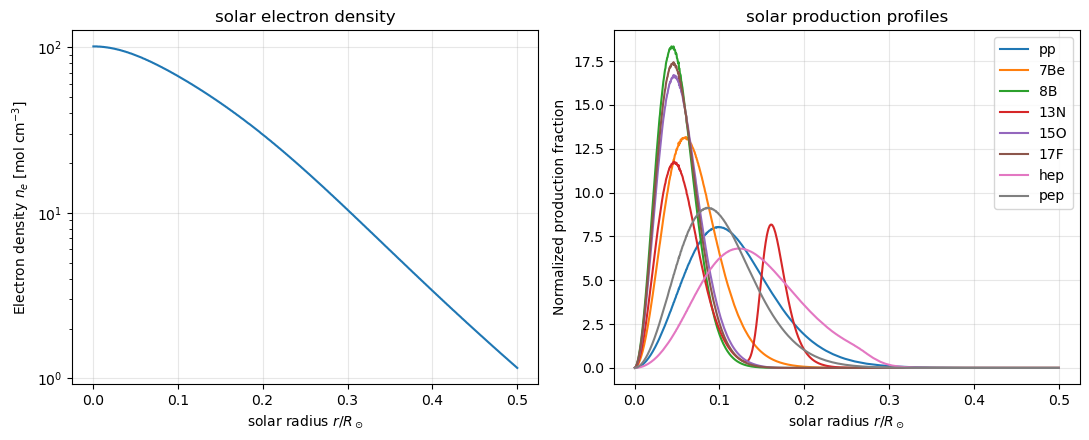

PASSED: plot_solar_profile()


In [7]:
run_notebook_call('plot_solar_profile()', lambda: TEST_MODULE.plot_solar_profile())
